In [1]:
# %% Setup
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # avoid libomp double-init abort (numpy and torch both bundle OpenMP on macOS)
os.environ.setdefault("OMP_NUM_THREADS", "1")           # avoids an OMP pthread_mutex_init segfault during inference on macOS

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import torch
from dotenv import load_dotenv
from tabpfn_time_series import TabPFNTSPipeline

# TabPFN needs a one-time license acceptance before it can download model weights for local
# inference (see https://ux.priorlabs.ai). The browser-based login flow this package normally
# uses to fetch a token hangs on Windows, so TABPFN_TOKEN is loaded from a local .env file
# (gitignored) instead of relying on that flow.
load_dotenv()

pipeline = TabPFNTSPipeline()   # device is auto-selected (uses CUDA when available)
print(f"Loaded TabPFN-TS (cuda available: {torch.cuda.is_available()})")

C:\Users\USER-PC\OneDrive\Documents\Masters\Masters-Forecasting\envs\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded TabPFN-TS (cuda available: True)


In [2]:
# %% Load and align data: states (targets) + exogenous inputs (covariates)
STATE_COLUMNS = {"C_A": "C_A", "T": "T", "T_C": "T_C", "h": "h", "Q_vec": "Q", "Q_c_vec": "Qc"}
EXOG_COLUMNS = {"F1": "E_R", "F2": "U_Ac", "F4": "T_F", "F5": "C_F", "F6": "T_CF", "F7": "Q_F"}

DOWNSAMPLE = 20  # must match FACTOR in CSTR-Downsample.ipynb

with h5py.File(f"CSTR_SimulationData_ds{DOWNSAMPLE}.h5", "r") as f:
    data = {col: f[key][:, 0] for key, col in STATE_COLUMNS.items()}
    n = len(data["C_A"])

# state[j] corresponds to raw input index 1 + j, strided by DOWNSAMPLE to match the full-resolution input file
idx = 1 + np.arange(n) * DOWNSAMPLE

with h5py.File("CSTR_InputVectors.h5", "r") as f:
    for key, col in EXOG_COLUMNS.items():
        data[col] = f[key][idx, 0]
    flags = {key: f[f"{key}.plt"][idx] for key in EXOG_COLUMNS}

df = pd.DataFrame(data)
df["item_id"] = "cstr"
df["timestamp"] = pd.date_range("2026-01-01", periods=n, freq=f"{DOWNSAMPLE}s")
df = df[["item_id", "timestamp"] + list(STATE_COLUMNS.values()) + list(EXOG_COLUMNS.values())]
df.head()

,item_id,timestamp,C_A,T,T_C,h,Q,Qc,E_R,U_Ac,T_F,C_F,T_CF,Q_F
0,cstr,2026-01-01 00:00:00,0.042680,402.235112,345.203306,0.600000,1.666657,0.249995,8750.0,833.333333,319.974511,0.999984,300.000496,1.666687
1,cstr,2026-01-01 00:00:20,0.036173,402.747833,344.968421,0.600167,1.666310,0.263921,8750.0,833.333333,319.934461,0.999772,300.017229,1.666107
2,cstr,2026-01-01 00:00:40,0.038006,401.882899,344.616651,0.600123,1.665862,0.256489,8750.0,833.333333,319.869430,0.999928,300.021288,1.665757
3,cstr,2026-01-01 00:01:00,0.038446,401.731625,344.730512,0.600103,1.666388,0.252465,8750.0,833.333333,319.971990,1.000179,300.026596,1.665872
4,cstr,2026-01-01 00:01:20,0.038290,401.815817,344.853108,0.600071,1.665903,0.252479,8750.0,833.333333,320.045624,0.999929,300.002199,1.665687


In [3]:
# %% Pick a forecast window
events = []
for key in EXOG_COLUMNS:
    active = np.where(flags[key] > 0)[0]
    if len(active) == 0:
        continue
    breaks = np.where(np.diff(active) > 1)[0]
    starts = np.concatenate([[active[0]], active[breaks + 1]])
    ends = np.concatenate([active[breaks], [active[-1]]])
    events += [(s, e, EXOG_COLUMNS[key]) for s, e in zip(starts, ends)]
events.sort()

EVENT_INDEX = -2     # which fault event to forecast across, in time order; -1 = last = most available context
BUFFER = 100          # samples of steady state before the fault kept inside the forecast window (not the context)
PLOT_LEAD_IN = 500    # samples of history shown in the plot before the forecast - display only, doesn't affect what the model sees
HORIZON = None        # forecast horizon in samples - set an int yourself, or leave None to size it to the event (capped below)

event_start, event_end, event_name = events[EVENT_INDEX]
SPLIT = max(event_start - BUFFER, 0)          # everything before this is context
context_available = SPLIT
context_used = min(context_available, pipeline.max_context_length)
if HORIZON is None:
    HORIZON = min((event_end - SPLIT) + 500, n - SPLIT)   # TabPFN-TS has no fixed max prediction length, unlike Chronos-2

print(
    f"Forecasting across the {event_name} event: {context_available} samples of context available "
    f"({context_used} will actually be used - pipeline max is {pipeline.max_context_length}), horizon = {HORIZON} steps"
)

Forecasting across the C_F event: 4315 samples of context available (4315 will actually be used - pipeline max is 32768), horizon = 685 steps


In [4]:
# %% Run TabPFN-TS with past states + past-and-future exogenous inputs
# TabPFN-TS is single-target (one regression call per series), unlike Chronos-2's multi-target predict_df -
# so this loops over the 6 states, reusing the same known-future exogenous inputs as covariates each time.
QUANTILES = [0.1, 0.5, 0.9]

context_df = df.iloc[:SPLIT].copy()
future_df = df.iloc[SPLIT:SPLIT + HORIZON][["item_id", "timestamp"] + list(EXOG_COLUMNS.values())].copy()
truth_df = df.iloc[SPLIT:SPLIT + HORIZON].copy()

preds = {}
for col in STATE_COLUMNS.values():
    ctx = context_df[["item_id", "timestamp", col] + list(EXOG_COLUMNS.values())].rename(columns={col: "target"})
    pred_df = pipeline.predict_df(ctx, future_df=future_df, quantiles=QUANTILES)
    preds[col] = pred_df.reset_index()   # columns: item_id, timestamp, target, 0.1, 0.5, 0.9 (quantile columns keyed by float, not string)

preds["C_A"].head()

GPU 0::   0%|          | 0/1 [00:00<?, ?it/s]

GPU 0:: 100%|██████████| 1/1 [00:05<00:00,  5.36s/it]

GPU 0:: 100%|██████████| 1/1 [00:05<00:00,  5.36s/it]

GPU 0::   0%|          | 0/1 [00:00<?, ?it/s]

GPU 0:: 100%|██████████| 1/1 [00:04<00:00,  4.18s/it]

...

GPU 0:: 100%|██████████| 1/1 [00:03<00:00,  3.97s/it]

GPU 0::   0%|          | 0/1 [00:00<?, ?it/s]

GPU 0:: 100%|██████████| 1/1 [00:04<00:00,  4.25s/it]

GPU 0:: 100%|██████████| 1/1 [00:04<00:00,  4.25s/it]

,item_id,timestamp,target,0.1,0.5,0.9
0,cstr,2026-01-01 23:58:20,0.037200,0.036891,0.037200,0.037530
1,cstr,2026-01-01 23:58:40,0.037267,0.036915,0.037267,0.037635
2,cstr,2026-01-01 23:59:00,0.037335,0.036968,0.037335,0.037731
3,cstr,2026-01-01 23:59:20,0.037342,0.036906,0.037342,0.037824
4,cstr,2026-01-01 23:59:40,0.037414,0.036902,0.037414,0.037995


C_A: MAE = 0.0043683
T: MAE = 2.0368
T_C: MAE = 3.6511
h: MAE = 1.6685e-05
Q: MAE = 0.00066759
Qc: MAE = 0.012553


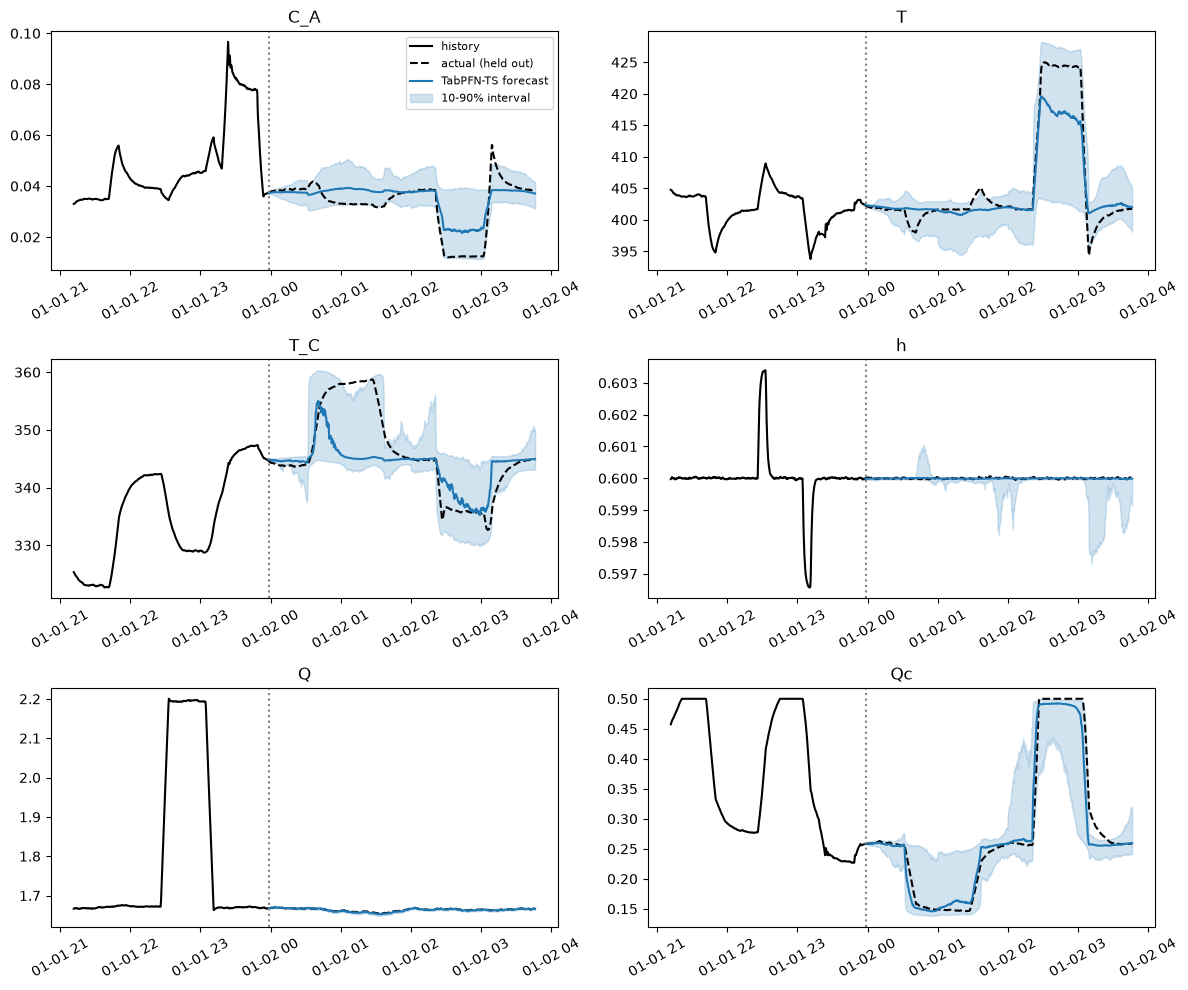

In [5]:
# %% Accuracy vs. the held-out actual simulation, and plots per state
for col in STATE_COLUMNS.values():
    sub = preds[col]
    mae = np.mean(np.abs(sub["target"].values - truth_df[col].values))
    print(f"{col}: MAE = {mae:.5g}")

context_tail = context_df.iloc[-PLOT_LEAD_IN:]
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
for ax, col in zip(axes.ravel(), STATE_COLUMNS.values()):
    sub = preds[col]
    ax.plot(context_tail["timestamp"], context_tail[col], color="black", label="history")
    ax.plot(truth_df["timestamp"], truth_df[col], color="black", linestyle="--", label="actual (held out)")
    ax.plot(sub["timestamp"], sub["target"], color="tab:blue", label="TabPFN-TS forecast")
    ax.fill_between(sub["timestamp"], sub[0.1], sub[0.9], color="tab:blue", alpha=0.2, label="10-90% interval")
    ax.axvline(truth_df["timestamp"].iloc[0], color="gray", linestyle=":")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
axes.ravel()[0].legend(fontsize=8)
fig.tight_layout()